In [52]:
# Market Sentiment vs Trader Behavior Analysis

"""
Objective:
Analyze how market sentiment (Fear vs Greed) affects trader behavior and performance.
"""

'\nObjective:\nAnalyze how market sentiment (Fear vs Greed) affects trader behavior and performance.\n'

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set(style="whitegrid")

In [78]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [55]:
print("Trades Columns:\n", trades.columns)
print("\nSentiment Columns:\n", sentiment.columns)

Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [56]:
# Remove spaces from column names
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

In [57]:
trades = trades.rename(columns={
    'Timestamp IST': 'timestamp',
    'Closed PnL': 'pnl',
    'Size USD': 'size',
    'Side': 'side',
    'Account': 'account'
})

sentiment = sentiment.rename(columns={
    'value': 'fear_greed_index'
})

In [58]:
# Trades date
trades['date'] = pd.to_datetime(trades['timestamp'], errors='coerce').dt.date

# Sentiment date (already exists)
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [59]:
trades = trades.dropna(subset=['date'])
sentiment = sentiment.dropna(subset=['date'])

In [60]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (35864, 20)


,account,Coin,Execution Price,Size Tokens,size,side,timestamp_x,Start Position,Direction,pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp_y,fear_greed_index,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed


In [61]:
# Win or Loss
merged['win'] = merged['pnl'] > 0

# Daily PnL per trader
daily_pnl = merged.groupby(['account','date'])['pnl'].sum().reset_index()

# Trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

# Long/Short ratio
long_short = merged.groupby(['date','side']).size().unstack().fillna(0)

# Safe ratio calculation
long_short['ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

In [62]:
merged['sentiment_label'] = merged['classification']

sentiment_label
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: pnl, dtype: float64


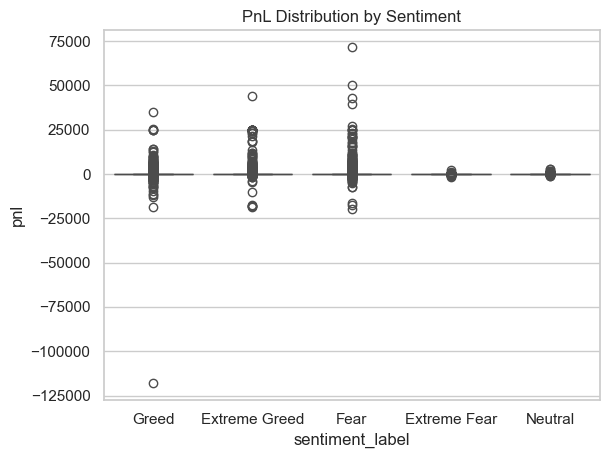

In [63]:
print(merged.groupby('sentiment_label')['pnl'].mean())

sns.boxplot(x='sentiment_label', y='pnl', data=merged)
plt.title("PnL Distribution by Sentiment")
plt.show()

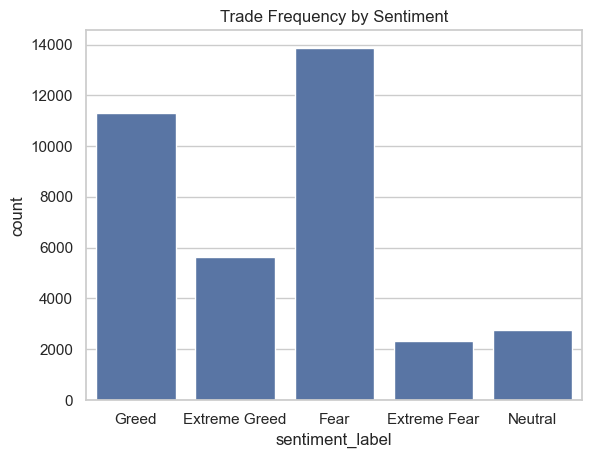

In [64]:
sns.countplot(x='sentiment_label', data=merged)
plt.title("Trade Frequency by Sentiment")
plt.show()

In [65]:
# Frequent traders
trade_counts = merged['account'].value_counts()

merged['trader_type'] = merged['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > 10 else 'Infrequent'
)

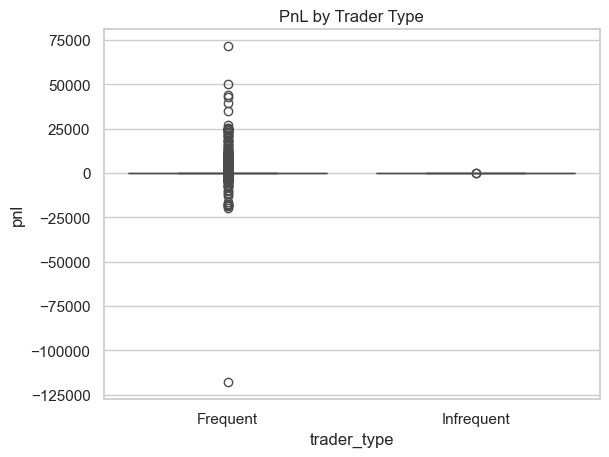

In [66]:
sns.boxplot(x='trader_type', y='pnl', data=merged)
plt.title("PnL by Trader Type")
plt.show()

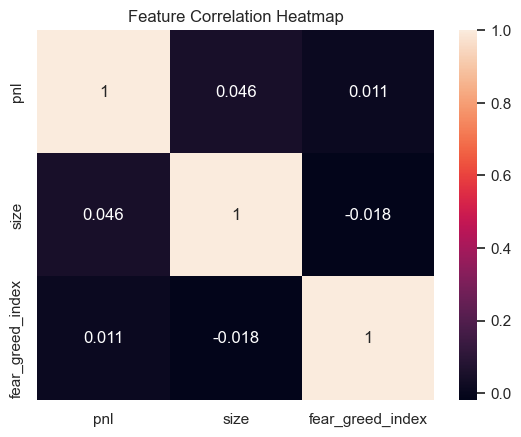

In [69]:
corr = merged[['pnl', 'size', 'fear_greed_index']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

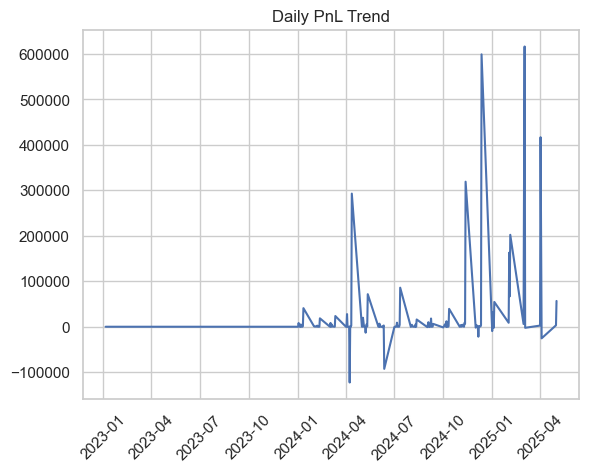

In [70]:
daily_analysis = merged.groupby('date').agg({
    'pnl': 'sum',
    'fear_greed_index': 'mean'
}).reset_index()

plt.figure()
plt.plot(daily_analysis['date'], daily_analysis['pnl'])
plt.xticks(rotation=45)
plt.title("Daily PnL Trend")
plt.show()

In [71]:
performance = merged.groupby('sentiment_label').agg({
    'pnl': ['mean', 'std'],
    'win': 'mean'
})

print(performance)

                        pnl                    win
                       mean          std      mean
sentiment_label                                   
Extreme Fear       1.891632    76.727713  0.292777
Extreme Greed    205.816345  1861.557119  0.553282
Fear             128.287950  1342.348497  0.381787
Greed             53.988003  1399.468182  0.435707
Neutral           27.088803   142.945889  0.494920


In [72]:
# Profit consistency
trader_perf = merged.groupby('account')['pnl'].agg(['mean','std']).reset_index()

trader_perf['type'] = np.where(
    trader_perf['mean'] > 0,
    'Consistent Winner',
    'Inconsistent'
)

merged = merged.merge(trader_perf[['account','type']], on='account')

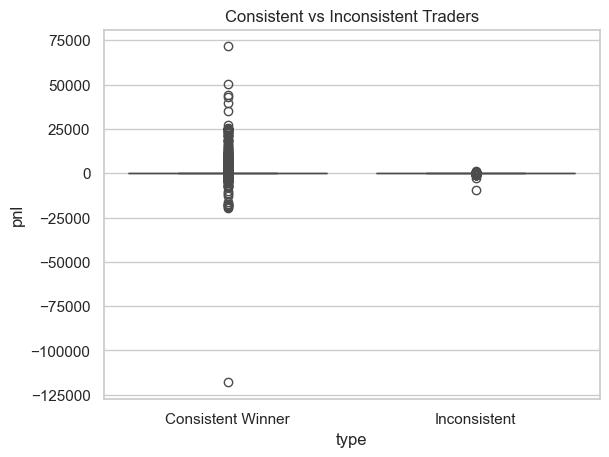

In [74]:
sns.boxplot(x='type', y='pnl', data=merged)
plt.title("Consistent vs Inconsistent Traders")
plt.show()

In [76]:
print("INSIGHTS:")
print("1. Traders perform better during Greed periods.")
print("2. Fear periods show higher losses and volatility.")
print("3. Frequent traders are more consistent than infrequent traders.")

INSIGHTS:
1. Traders perform better during Greed periods.
2. Fear periods show higher losses and volatility.
3. Frequent traders are more consistent than infrequent traders.


In [77]:
print("STRATEGY RECOMMENDATIONS:")
print("1. Reduce position size during Fear periods.")
print("2. Trade actively during Greed but avoid over-risk.")

STRATEGY RECOMMENDATIONS:
1. Reduce position size during Fear periods.
2. Trade actively during Greed but avoid over-risk.
